# Imports

In [57]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage, ToolMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langgraph.prebuilt import ToolNode, tools_condition # for tools conditions
from langchain_core.documents import Document # for document
# youtube search tool
from langchain_community.tools import YouTubeSearchTool
from langchain_community.document_loaders import YoutubeLoader
import ast # convert string into actual python list
# wikipedia search tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
# google search tools
import os
from langchain_community.utilities import SearchApiAPIWrapper
from langchain_core.tools import Tool
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List

# Model

In [58]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Tools

In [59]:
rag_tools = []
web_tools = []

loading csv data

In [60]:
all_docs = []

for csv_path in ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed//question_answer.csv"]:
    if os.path.exists(csv_path):
        loader = CSVLoader(file_path=csv_path, encoding="latin1")
        docs = loader.load()  # Each row = 1 Document
        all_docs.extend(docs)  # Keep Document objects

chunking docs

In [61]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=500)
texts = text_splitter.split_documents(all_docs)

storing results in FAISS vector store.

In [62]:
vector_db = FAISS.from_documents(texts, embeddings)

vector search tool

In [63]:
@tool("vector_search", description="Search the device manuals database for relevant documents.")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    retriever = vector_db.as_retriever(search_type='similarity', search_kwargs={'k': 5})
    result = retriever.invoke(query)
    context = "\n\n".join([doc.page_content for doc in result])
    return context
rag_tools.append(vector_search)

youtube search

In [64]:
@tool("fetch_youtube_content", description="finds youtube videos using YoutubeSearchTool and then fetches content of the link using YoutubeLoader")
def fetch_youtube_content(query: str) -> str:
    """
    Fetches the full transcript text from a YouTube video link.
    """
    youtube_tool = YouTubeSearchTool()

    raw_result = youtube_tool.run(query)
    video_ids = ast.literal_eval(raw_result)
    links = [vid for vid in video_ids]

    all_text = ""
    i = 0
    for link in links:
      all_text += f"Video {i + 1} Content: "
      loader = YoutubeLoader.from_youtube_url(
          link,
          add_video_info=False,
      )
      doc = loader.load()
      all_text += doc[0].page_content + "\n"
      i = i + 1

    return all_text
web_tools.append(fetch_youtube_content)

wikipedia search tool

In [65]:
wikiSearch = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
web_tools.append(wikiSearch)

google web search tool

In [66]:
# 1) Google Web Search
google_web = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google",            # standard Google web search
)

google_web_tool = Tool(
    name="google_web_search",
    description="General Google web search via SearchApi.io.",
    func=google_web.run,
)

web_tools.append(google_web_tool)

google news search tool

In [67]:
# 2) Google News
google_news = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_news",       # Google News vertical
)

google_news_tool = Tool(
    name="google_news_search",
    description="Latest news headlines and articles via Google News (SearchApi.io).",
    func=google_news.run,
)

web_tools.append(google_news_tool)

google scholar search

In [68]:
# 3) Google Scholar
google_scholar = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_scholar",    # Google Scholar vertical
)

google_scholar_tool = Tool(
    name="google_scholar_search",
    description="Academic papers and scholarly articles via Google Scholar (SearchApi.io).",
    func=google_scholar.run,
)

web_tools.append(google_scholar_tool)

binding LLM with tools

In [69]:
llm_with_rag_tools = llm.bind_tools(rag_tools)
llm_with_web_tools = llm.bind_tools(web_tools)

# Lang graph state

In [196]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    phase: str # current phase of the chat web or rag

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [227]:
def planning(state: ChatState):

   fixed_spelling = llm.invoke(f"Fix the spelling, syntax and any other errors in the question and just give question donot give maything else: {state['question']}.").content
   SYSTEM_PROMPT = """
You are an Agentic RAG assistant.

You MUST follow these rules exactly:

1. Mandatory Vector Retrieval:
   - For EVERY user question, you MUST call the `vector_search` tool first.
   - You are NOT allowed to answer the question before calling `vector_search`.
   - Use the 'vector_search' tool just once. If the context is not retrieved properly then move on and never use this tool ever again.

2. Multi-part Query Handling:
   - If the user question contains multiple distinct inquiries (e.g., "Tell me about X and who is Y?"), you MUST ensure that you address ALL parts.
   - You may call multiple tools or call them sequentially to gather information for each part.

3. Context Evaluation:
   - After receiving the `vector_search` output, evaluate whether the context is sufficient and relevant for the ENTIRE question.

4. Web Search Escalation (ONLY if vector context is insufficient):
   - You MUST perform a web search using the most appropriate tool based on the question type.

5. Web Search Tool Selection Rules:
   - Use `google_web_search` for:
     - General factual information
     - Definitions, biographies, overviews
     - Broad or mixed-topic queries

   - Use `wikipedia` for:
     - Encyclopedic knowledge
     - Historical facts
     - Well-established people, organizations, or concepts

   - Use `google_scholar_search` for:
     - Academic, scientific, or research-related questions
     - Peer-reviewed papers, citations, theories, or studies

   - Use `google_news_search` for:
     - Recent events, breaking news, or time-sensitive information
     - Current affairs, announcements, or trending topics

   - Use `fetch_youtube_content` for:
     - Tutorials, demonstrations, lectures, or talks
     - Visual or step-by-step explanations

6. Web Search Retry Logic:
   - If the selected web search tool returns insufficient or irrelevant information for ANY part of the question:
     - You MUST try another appropriate web search tool.
     - You MAY call multiple web search tools sequentially until all parts of the question are addressed.

7. Tool Usage Restrictions:
   - You are ONLY allowed to use tools that have been registered.
   - DO NOT invent tool names.
   - DO NOT call unregistered tools.
   - If no suitable web search tool is available, explicitly state that more information is required.

8. Knowledge Grounding:
   - NEVER answer from internal knowledge unless you have exhausted all search tools and still have no information.
   - ALL answers SHOULD be grounded in retrieved tool context whenever possible.

9. Tool Call Format:
   - When calling a tool, output ONLY a valid tool call.
   - Do NOT include explanations, reasoning, or natural language ALONGSIDE a tool call.
   - HOWEVER, if you are refusing to answer due to safety guidelines, or if you need to provide a disclaimer, you SHOULD use natural language.

Failure to follow these rules is not allowed. Strictly follow all these rules.
REMINDER: USE vector_search TOOL JUST ONCE AND ONLY ONCE.
"""

   system = SystemMessage(
      content=SYSTEM_PROMPT  
   )
   user = HumanMessage(content=fixed_spelling)

   return {
      "messages": [system, user],
      "question": fixed_spelling,
      "phase": "rag"
   }


context search node (this node will bring the context from evaluating rag)

In [228]:
def context_search(state: ChatState):
    
    if any(isinstance(msg, ToolMessage) for msg in state['messages']):
        return {"messages": []}
        
    ai_response = llm_with_rag_tools.invoke(state["messages"])
    return {"messages": [ai_response]}


check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [ ]:
def check_relevence(state: ChatState):
    
    reversed_iterator = reversed(state["messages"])
    tool_outputs = []
    
    for msg in reversed_iterator:
        if isinstance(msg, ToolMessage):
            tool_outputs.append(msg.content)

    if len(tool_outputs) >= 6:
        return {"phase": "fall_back_llm"}
            
    context_str = "\n---\n".join(reversed(tool_outputs))

    judge_prompt = f"""
    Question: {state['question']}
    Context:
    {context_str}

    Review the context above and determine if it provides a COMPLETE answer to ALL parts of the user's question: "{state['question']}".
    If ANY part of the question cannot be answered using the provided context, respond with NO.
    Only respond with YES if EVERYTHING in the question can be answered using only the provided context.
    Reply only YES or NO.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()

    if "YES" in decision:
        return {"phase": "end"}
    else:
        return {"phase": "web"}


fallback llm node

In [230]:
def fallback_llm_answer(state: ChatState):
    prompt = f"""
    Answer the following question using your general knowledge.
    Do NOT use tools.
    Do NOT give medical instructions.
    Keep the answer high-level and educational.

    Question: {state['question']}
    """

    answer = llm.invoke(prompt).content

    return {
        "messages": [AIMessage(content=answer)],
        "phase": "end"
    }


web search node (this node will decide give us web search results)

In [231]:
def web_search(state: ChatState):
    
    ai_response = llm_with_web_tools.invoke(state["messages"])
    
    return {"messages": [ai_response]}


In [232]:
def should_continue_web(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return state["phase"]

# Graph

In [233]:
graph = StateGraph(ChatState)

tools node

In [234]:
rag_tool_node = ToolNode(rag_tools)
web_tool_node = ToolNode(web_tools)

creating all nodes

In [235]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node('rag_tools', rag_tool_node)
graph.add_node('web_tools', web_tool_node)
graph.add_node("fallback_llm", fallback_llm_answer)

creating add edges

In [236]:
graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_conditional_edges('context_search', tools_condition, {"tools": "rag_tools", "__end__": "check_relevence"})
graph.add_edge('rag_tools', 'context_search')
graph.add_conditional_edges("check_relevence", should_continue_web, {"web": "web_search", "end": END, "fallback_llm": "fallback_llm"})
graph.add_conditional_edges('web_search', tools_condition, {"tools": "web_tools", "__end__": "check_relevence"})
graph.add_edge("web_tools", "web_search")
graph.add_edge("fallback_llm", END)

compiling graph

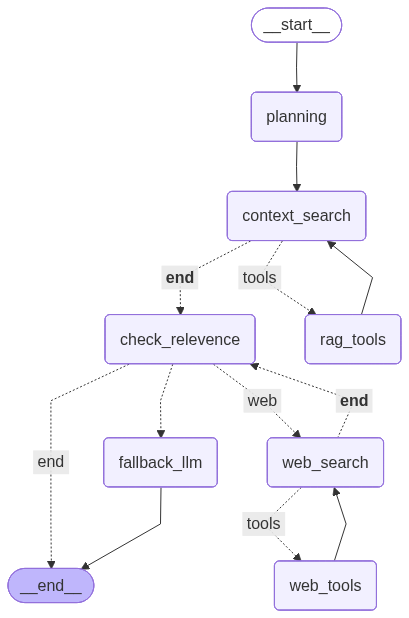

In [237]:
chatbot = graph.compile()
chatbot

# Question to agent

In [238]:
initial_state = {
    'question': "tell me information about rabbies? and tell me about who is geo ferry hinton?"
}

res = chatbot.invoke(initial_state)
res

{'question': 'Tell me information about rabies? \nAnd tell me about who is Geoffrey Hinton?',
 'messages': [SystemMessage(content='\nYou are an Agentic RAG assistant.\n\nYou MUST follow these rules exactly:\n\n1. Mandatory Vector Retrieval:\n   - For EVERY user question, you MUST call the `vector_search` tool first.\n   - You are NOT allowed to answer the question before calling `vector_search`.\n   - Use the \'vector_search\' tool just once. If the context is not retrieved properly then move on and never use this tool ever again.\n\n2. Multi-part Query Handling:\n   - If the user question contains multiple distinct inquiries (e.g., "Tell me about X and who is Y?"), you MUST ensure that you address ALL parts.\n   - You may call multiple tools or call them sequentially to gather information for each part.\n\n3. Context Evaluation:\n   - After receiving the `vector_search` output, evaluate whether the context is sufficient and relevant for the ENTIRE question.\n\n4. Web Search Escalation

In [239]:
ai_msg = res["messages"][-1].content
ai_msg

'Rabies is a deadly animal disease caused by a virus. It can happen in wild animals, including raccoons, skunks, bats and foxes, or in dogs, cats or farm animals. People get it from the bite of an infected animal. In people, symptoms of rabies include fever, headache and fatigue, then confusion, hallucinations and paralysis. Once the symptoms begin, the disease is usually fatal. A series of shots can prevent rabies in people exposed to the virus.\n\nGeoffrey Hinton is a British-Canadian computer scientist, cognitive scientist, and cognitive psychologist known for his work on artificial neural networks, which earned him the title "the Godfather of AI". He is University Professor Emeritus at the University of Toronto and has made significant contributions to the field of deep learning. Hinton, along with Yoshua Bengio and Yann LeCun, received the 2018 Turing Award for their work on deep learning.'